In [21]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [22]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import cm
import OscTools as osc
from OscTools import plot_tools as pt
from OscTools import micro_tools as micro
from OscTools import mini_tools as mini
from OscTools import apps
from OscTools import param_scan

try:
    from importlib.resources import files
except ImportError:
    from importlib_resources import files


In [23]:
dic_osc_full = param_scan.load_scan_data('fit_data/fits_before_May6/MH_numu_MC_keep_numu_norm.pkl')
bf_osc_full = param_scan.get_best_fit_point(dic_osc_full)

pointAcolor = 'dodgerblue'
pointBcolor = 'deeppink'

In [24]:
bf_osc_full

{'g': np.float64(1e-10),
 'm4': np.float64(0.44984326689694454),
 'Ue4Sq': np.float64(0.018486873582389367),
 'Um4Sq': np.float64(0.5),
 'sin2theta': np.float64(0.036974),
 'dm4SQR': np.float64(0.20235896477251566),
 'MiniApp_chi2': np.float64(36.26918072449617),
 'MicroApp_chi2': np.float64(113.7536758714175),
 'MicroApp_Asimov_chi2': np.float64(14.501561272313172),
 'MiniApp_deltachi2': np.float64(0.0),
 'MicroApp_deltachi2': np.float64(23.744059674768295),
 'MicroApp_Asimov_deltachi2': np.float64(11.690719536619298)}

In [25]:
def get_best_fit_point(dic, Umu4SQRmax=1, Ue4SQRmax=1, dm4SQRmin=1e-2):
    mask = (
        (dic["Umu4SQR"] < Umu4SQRmax)
        & (dic["Ue4SQR"] < Ue4SQRmax)
        & (dic["dm4SQR"] > dm4SQRmin)
    )
    argmin = np.argmin(dic["MicroApp_chi2"][mask])
    dic_best_fit = {}
    for key in dic.keys():
        if key == "Ue4SQR":
            new_key = "Ue4Sq"
        elif key == "Umu4SQR":
            new_key = "Um4Sq"
        else:
            new_key = key
        dic_best_fit[new_key] = dic[key][mask][argmin]
    return dic_best_fit

bf_osc_micro = get_best_fit_point(dic_osc_full)
bf_osc_micro['MicroApp_chi2']

np.float64(90.0096161966492)

## MiniBooNE nu_e sample

In [26]:
# settings for Mini Figs
TOTAL_RATE = False
INCLUDE_MB_LAST_BIN = False
STACKED = False
PLOT_FAMILY=False
PATH_PLOTS = 'plots/event_rates/'

PAPER_TAG = r'HKZ\,2024'

In [27]:
Weight_nue_flux = apps.reweight_MC_to_nue_flux(
            param_scan.Etrue_nue, param_scan.Weight_nue, mode="fhc"
        )

MC_nue_bkg_intrinsic = np.dot(
                param_scan.fast_histogram(
                    param_scan.Etrue_nue, bins=param_scan.e_prod_e_int_bins, weights=Weight_nue_flux
                )[0],
                apps.migration_matrix_official_bins_nue_11bins,
            )

In [28]:
import scipy
from scipy.stats import norm
def get_pval(rates_dic, ndof=8.7):
    MB_chi2 = mini.chi2_MiniBooNE_combined(
                MC_nue_app=rates_dic["MC_nue_app"],
                MC_nuebar_app=rates_dic["MC_nuebar_app"],
                MC_nue_dis=rates_dic["MC_nue_bkg_total_w_dis"],
                MC_numu_dis=rates_dic["MC_numu_bkg_total_w_dis"],
                MC_nuebar_dis=rates_dic["MC_nuebar_bkg_total_w_dis"],
                MC_numubar_dis=rates_dic["MC_numubar_bkg_total_w_dis"],
                year="2020",
            )
    return scipy.stats.chi2.sf(MB_chi2, ndof)


def get_pval_nu(rates_dic, ndof=8.7):
    MB_chi2 = mini.chi2_MiniBooNE_combined(
                MC_nue_app=rates_dic["MC_nue_app"],
                MC_nue_dis=rates_dic["MC_nue_bkg_total_w_dis"],
                MC_numu_dis=rates_dic["MC_numu_bkg_total_w_dis"],
                year="2020",
            )
    return scipy.stats.chi2.sf(MB_chi2, ndof)

In [29]:
import matplotlib as mpl


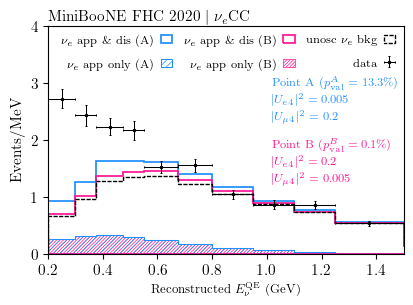

In [32]:
fig, ax = pt.std_fig(figsize=(4.5,3))
bins = param_scan.MB_Ereco_official_bins
bin_w = np.diff(bins)
bin_c = bins[:-1] + bin_w/2

######################################
# MiniBooNE 
if TOTAL_RATE:
    units= 1
    ax.set_ylabel(r"Events")
else:
    units = 1/mini.bin_width
    ax.set_ylabel(r"Events/MeV")

nue_data = np.genfromtxt(
    files(f"OscTools.include.MB_data_release_2020.combined").joinpath("miniboone_nuedata_lowe.txt").open()
)
nue_tot_bkg = np.genfromtxt(
            files(f"OscTools.include.MB_data_release_2020.combined").joinpath("miniboone_nuebgr_lowe.txt").open()
        )
nue_bkg_midID = nue_tot_bkg - MC_nue_bkg_intrinsic

if TOTAL_RATE:
    units= 1
else:
    units = 1/mini.bin_width

params_BSM1 = {'g': 1e-10, 'Ue4Sq': 0.005, 'Um4Sq': 0.2, 'm4': np.sqrt(0.429)}
rates_BSM1 = param_scan.get_nue_rates(params_BSM1, oscillations=True, use_numu_MC=True, include_antineutrinos=True, decay=False, decouple_decay=False, disappearance=True, energy_degradation=True, n_replications=1, undo_numu_normalization=False)

# params_BSM1 = {'g': 1e-10, 'Ue4Sq': 0.5*3/2, 'Um4Sq': 2e-3*2/3, 'm4': np.sqrt(100)}
# rates_BSM1 = param_scan.get_nue_rates(params_BSM1, oscillations=True, use_numu_MC=True, include_antineutrinos=True, decay=False, decouple_decay=False, disappearance=True, energy_degradation=True, n_replications=1, undo_numu_normalization=False)

params_BSM2 = {'g': 1e-10, 'Ue4Sq': 0.2, 'Um4Sq': 0.005, 'm4': np.sqrt(0.429)}
rates_BSM2 = param_scan.get_nue_rates(params_BSM2, oscillations=True, use_numu_MC=True, include_antineutrinos=True, decay=False, decouple_decay=False, disappearance=True, energy_degradation=True, n_replications=1, undo_numu_normalization=False)

ax.hist(bins[:-1],
        bins=bins,
        # weights=(nue_tot_bkg)*units,
        weights=(rates_BSM1['MC_nue_app']+rates_BSM1['MC_nue_bkg_total_w_dis'] - nue_bkg_midID)*units,
        edgecolor=pointAcolor,
        facecolor='None',
        lw=1.25,
        label=r'$\nu_e$ app \& dis (A)',
        histtype='stepfilled',
        zorder=1.5)

mpl.rcParams['hatch.linewidth'] = 0.4  # previous pdf hatch linewidth
ax.hist(bins[:-1],
        bins=bins,
        weights=(rates_BSM1['MC_nue_app']+0*nue_bkg_midID)*units,
        # weights=(rates_dic_osc['MC_nue_app'] + nue_tot_bkg)*units,
        edgecolor=pointAcolor,
        facecolor='None',
        lw=0.75,
        hatch=5*'/',
        linestyle=(1,(3,0)),
        label=r'$\nu_e$ app only (A)',
        histtype='stepfilled',
        zorder=1.4)


ax.hist(bins[:-1],
        bins=bins,
        # weights=(nue_tot_bkg)*units,
        weights=(rates_BSM2['MC_nue_app']+rates_BSM2['MC_nue_bkg_total_w_dis'] - nue_bkg_midID)*units,
        edgecolor=pointBcolor,
        facecolor='None',
        lw=1.25,
        ls=(1,(3,0)),
        label=r'$\nu_e$ app \& dis (B)',
        histtype='stepfilled',
        zorder=1.5)

mpl.rcParams['hatch.linewidth'] = 0.5  # previous pdf hatch linewidth
ax.hist(bins[:-1],
        bins=bins,
        weights=(rates_BSM1['MC_nue_app']+0*nue_bkg_midID)*units,
        # weights=(rates_dic_osc['MC_nue_app'] + nue_tot_bkg)*units,
        edgecolor=pointBcolor,
        facecolor='None',
        lw=0.5,
        hatch=10*'/',
        linestyle=(1,(3,0)),
        label=r'$\nu_e$ app only (B)',
        histtype='stepfilled',
        zorder=1.3)
# ax.hist(bins[:-1],
#         bins=bins,
#         weights=(rates_BSM2['MC_nue_app']+nue_bkg_midID)*units,
#         # weights=(rates_dic_osc['MC_nue_app'] + nue_tot_bkg)*units,
#         edgecolor='black',
#         facecolor='None',
#         lw=1.5,
#         linestyle=(1,(3,0)),
#         label=r'$\nu_\mu \to \nu_e$ appearance',
#         histtype='stepfilled',
#         zorder=1.6)


# plot data
pt.data_plot(ax, 
        X=bin_c,
        Y=(nue_data-nue_bkg_midID)*units, 
        xerr=bin_w/2, 
        yerr=np.sqrt(nue_data-nue_bkg_midID)*units,
        zorder=3)

ax.hist(bins[:-1],
        bins=bins,
        weights=(nue_tot_bkg - nue_bkg_midID)*units,
        edgecolor='black',
        lw=1.0,
        ls=(1,(3,1)),
        label=r'unosc $\nu_e$ bkg',
        histtype='step',
        zorder=1.6)
# ax.hist(bins[:-1],
#         bins=bins,
#         weights=(nue_bkg_midID)*units,
#         edgecolor='black',
#         facecolor='lightgrey',
#         lw=0.5,
#         label=r'misID bkg',
#         histtype='stepfilled',
#         zorder=2)

ax.set_xlabel(r"Reconstructed $E_\nu^{\rm QE}$ (GeV)", fontsize=9, labelpad=2.5)
if INCLUDE_MB_LAST_BIN:
    ax.set_xticks([0.2,0.5,1,1.5,2,2.5,3])
    ax.set_xlim(0.2,3)
else:
    ax.set_xticks([0.2,0.4,0.6,0.8,1,1.2,1.4])
    ax.set_xlim(0.2,1.5)
ax.set_ylim(0,4)

ax.legend(fontsize=8.5, markerfirst=False, ncol=3, handlelength=1, loc='upper right', borderpad=0.2, labelspacing=1, handletextpad=0.5, columnspacing=1)

x_box = 0.63
ax.annotate(text=r'MiniBooNE FHC 2020 $\vert$ $\nu_e$CC', xy=(0.0,1.025), xycoords='axes fraction', fontsize=11)
# ax.annotate(text=rf'\noindent $\Delta m^2 = {params_BSM1["m4"]**2:.2f}$ eV$^2$', 
#                 xy=(0.44,0.5), 
#                 xycoords='axes fraction', 
#                 fontsize=8.5,
#                 bbox=dict(facecolor='none', edgecolor='black', linewidth=0.0, boxstyle='square,pad=0.3'),
#                 multialignment='left')
ax.annotate(text=rf'Point A'+fr' ($p_{{\rm val}}^{{A}} = {get_pval(rates_BSM1, 38-5)*100:.1f}\%$)', 
                xy=(x_box,0.73+0.01), 
                xycoords='axes fraction', 
                fontsize=8.5,
                color=pointAcolor,
                multialignment='left')
ax.annotate(text=rf'Point B'+fr' ($p_{{\rm val}}^{{B}} = {get_pval(rates_BSM2, 38-5)*100:.1f}\%$)', 
                xy=(x_box,0.46+0.01), 
                xycoords='axes fraction', 
                fontsize=8.5,
                color=pointBcolor,
                multialignment='left')

ax.annotate(text=rf'\noindent $|U_{{e4}}|^2 = {params_BSM1["Ue4Sq"]:.3f}$\\$|U_{{\mu 4}}|^2 = {params_BSM1["Um4Sq"]:.1f}$', 
                xy=(x_box,0.66), 
                xycoords='axes fraction', 
                fontsize=8.5,
                color=pointAcolor,
                bbox=dict(facecolor='none', edgecolor='black', linewidth=0.0, boxstyle='square,pad=0.3'),
                multialignment='left')

ax.annotate(text=rf'\noindent $|U_{{e4}}|^2 = {params_BSM2["Ue4Sq"]:.1f}$\\$|U_{{\mu 4}}|^2 = {params_BSM2["Um4Sq"]:.3f}$', 
                xy=(x_box,0.39), 
                xycoords='axes fraction', 
                fontsize=8.5,
                color=pointBcolor,
                bbox=dict(facecolor='none', edgecolor='black', linewidth=0.0, boxstyle='square,pad=0.3'),
                multialignment='left')

# ax1.annotate(text=PAPER_TAG, xy=(1,1.025), xycoords='axes fraction', fontsize=8.5, ha='right')
# ax.annotate(text=, xy=(0.15,0.9), xycoords='axes fraction', fontsize=8.5)
# ax.annotate(text=, xy=(0.15,0.8), xycoords='axes fraction', fontsize=8.5)

fig.savefig(f"plots/mini_rate_pointsAandB.pdf", dpi=400)

# MicroBooNE rates

In [10]:
import copy
from OscTools.InclusiveTools.inclusive_osc_tools import (
    Decay_muB_OscChi2,
    DecayMuBNuMuDis,
    DecayMuBNuEDis,
)

In [33]:
def plot_BSM(ax, rates_BSM, params_BSM, color=pointAcolor, LABEL='A', nhatch=5):

    bins = np.array([0.0 + 0.1 * j for j in range(26)] + [10.0])
    bin_w = np.diff(bins)
    bin_c = bins[:-1] + bin_w/2

    # oscillation only MicroBooNE fully inclusive signal by unfolding MiniBooNE Signal
    uBFC_osc = param_scan.GBFC.unfold(rates_BSM["MC_nue_app_for_unfolding"])
    uBFC_osc = np.insert(uBFC_osc, 0, [0.0])
    uBFC_osc = np.append(uBFC_osc, 0.0)

    # MicroBooNE partially inclusive signal by unfolding MiniBooNE Signal
    MC_nue_app_for_unfolding2_osc = copy.deepcopy(rates_BSM["MC_nue_app_for_unfolding"])
    uBPC_osc = param_scan.GBPC.unfold(MC_nue_app_for_unfolding2_osc)
    uBPC_osc = np.insert(uBPC_osc, 0, [0.0])
    uBPC_osc = np.append(uBPC_osc, 0.0)

    uBtemp_osc = np.concatenate([uBFC_osc, uBPC_osc, np.zeros(85)])

    uB_signal_osc = uBFC_osc
    SAMPLE = "FC"
    other_bkg = np.load(files(micro.muB_inclusive_datarelease_path).joinpath(f'nueCC_{SAMPLE}_Bkg.npy').open('rb'))
    intrinsic_bkg = np.load(files(micro.muB_inclusive_datarelease_path).joinpath(f'nueCC_{SAMPLE}_Sig.npy').open('rb'))
    data = np.load(files(micro.muB_inclusive_datarelease_path).joinpath(f'nueCC_{SAMPLE}_Obs.npy').open('rb'))
    if TOTAL_RATE:
        units= 1
        ax.set_ylabel(r"Events")
    else:
        units = 1/bin_w/1e3
        ax.set_ylabel(r"Events/MeV")

    # \nu_e disappearance signal replacement (oscillation term -- lightgreen)
    NuEReps = DecayMuBNuEDis(
    params_BSM,
    oscillations=True,
    decay=False,
    decouple_decay=False,
    disappearance=True,
    energy_degradation=True,
    )

    # \nu_mu disappearance signal replacement
    NuMuReps = DecayMuBNuMuDis(
    params_BSM,
    oscillations=True,
    decay=True,
    decouple_decay=False,
    disappearance=True,
    energy_degradation=True,
    )

    # MicroBooNE
    MuB_chi2 = Decay_muB_OscChi2(
        params_BSM,
        uBtemp_osc,
        constrained=False,
        sigReps=[NuEReps[0], NuEReps[1], NuMuReps[0], NuMuReps[1], None, None, None],
        RemoveOverflow=True,
        oscillations=True,
        decay=False,
        decouple_decay=False,
        disappearance=True,
        energy_degradation=True,
    )
    print(f"Size of NuEReps[0]: {len(NuEReps[0])}")
    print(f"Size of NuEReps[1]: {len(NuEReps[1])}")
    print(f"Size of NuMuReps[0]: {len(NuMuReps[0])}")
    print(f"Size of NuMuReps[1]: {len(NuMuReps[1])}")


    ax.hist(bins[:-1],
            bins=bins,
            weights=(uB_signal_osc+NuEReps[0])*units,
            edgecolor=color,
            facecolor='None',
            lw=1.25,
            label=Fr'$\nu_e$ app \& dis ({LABEL})',
            histtype='stepfilled',
            zorder=1.6)
    

    mpl.rcParams['hatch.linewidth'] = 0.5  # previous pdf hatch linewidth
    ax.hist(bins[:-1],
            bins=bins,
            weights=(uB_signal_osc)*units,
            edgecolor=color,
            facecolor='None',
            lw=1.25,
            linestyle=(1,(3,0)),
            hatch=nhatch*'/',
            label=fr'$\nu_e$ app only ({LABEL})',
            histtype='stepfilled',
            zorder=1.4+(0.1 if LABEL=='A' else 0))

    return MuB_chi2

Size of NuEReps[0]: 26
Size of NuEReps[1]: 26
Size of NuMuReps[0]: 26
Size of NuMuReps[1]: 26
Size of NuEReps[0]: 26
Size of NuEReps[1]: 26
Size of NuMuReps[0]: 26
Size of NuMuReps[1]: 26


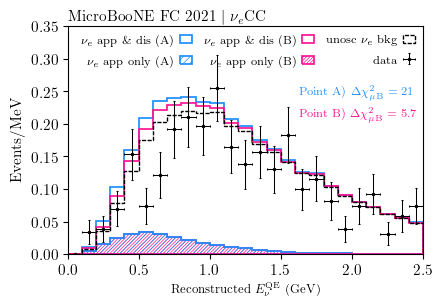

In [35]:
fig, ax = pt.std_fig(figsize=(4.5,3))

bins = np.array([0.0 + 0.1 * j for j in range(26)] + [10.0])
bin_w = np.diff(bins)
bin_c = bins[:-1] + bin_w/2

params_BSM1 = {'g': 1e-10, 'Ue4Sq': 0.005, 'Um4Sq': 0.2, 'm4': np.sqrt(0.429)}
rates_BSM1 = param_scan.get_nue_rates(params_BSM1, oscillations=True, use_numu_MC=True, include_antineutrinos=True, decay=False, decouple_decay=False, disappearance=True, energy_degradation=True, n_replications=1, undo_numu_normalization=False)

# params_BSM1 = {'g': 1e-10, 'Ue4Sq': 0.5*3/2, 'Um4Sq': 2e-3*2/3, 'm4': np.sqrt(100)}
# rates_BSM1 = param_scan.get_nue_rates(params_BSM1, oscillations=True, use_numu_MC=True, include_antineutrinos=True, decay=False, decouple_decay=False, disappearance=True, energy_degradation=True, n_replications=1, undo_numu_normalization=False)

params_BSM2 = {'g': 1e-10, 'Ue4Sq': 0.2, 'Um4Sq': 0.005, 'm4': np.sqrt(0.429)}
rates_BSM2 = param_scan.get_nue_rates(params_BSM2, oscillations=True, use_numu_MC=True, include_antineutrinos=True, decay=False, decouple_decay=False, disappearance=True, energy_degradation=True, n_replications=1, undo_numu_normalization=False)

MuB_chi2_1 = plot_BSM(ax, rates_BSM1, params_BSM1, color=pointAcolor, LABEL='A', nhatch=5)
MuB_chi2_2 = plot_BSM(ax, rates_BSM2, params_BSM2, color=pointBcolor, LABEL='B', nhatch=10)

###################################### 
if TOTAL_RATE:
    units= 1
    ax.set_ylabel(r"Events")
else:
    units = 1/bin_w/1e3
    ax.set_ylabel(r"Events/MeV")

SAMPLE = "FC"
other_bkg = np.load(files(micro.muB_inclusive_datarelease_path).joinpath(f'nueCC_{SAMPLE}_Bkg.npy'))
intrinsic_bkg = np.load(files(micro.muB_inclusive_datarelease_path).joinpath(f'nueCC_{SAMPLE}_Sig.npy'))
data = np.load(files(micro.muB_inclusive_datarelease_path).joinpath(f'nueCC_{SAMPLE}_Obs.npy'))

# plot data
pt.data_plot(ax, 
        X=bin_c,
        Y=(data-other_bkg)*units, 
        xerr=bin_w/2, 
        yerr=np.sqrt(data-other_bkg)*units,
        zorder=3)


ax.hist(bins[:-1],
        bins=bins,
        weights=(other_bkg*0 + intrinsic_bkg)*units,
        edgecolor='black',
        lw=1.0,
        ls=(1,(3,1)),
        label=r'unosc $\nu_e$ bkg',
        histtype='step',
        zorder=1.8)
# ax.hist(bins[:-1],
#         bins=bins,
#         weights=other_bkg*units,
#         edgecolor='black',
#         facecolor='lightgrey',
#         lw=0.5,
#         label=r'Non-$\nu_e$ bkg',
#         histtype='stepfilled',
#         zorder=1.7)

# ax.legend(loc='upper right', fontsize=8, markerfirst=False, ncol=3)
ax.legend(fontsize=8.5, markerfirst=False, ncol=3, handlelength=1, loc='upper right', borderpad=0.2, labelspacing=0.75, handletextpad=0.5, columnspacing=1)
ax.annotate(text=fr'MicroBooNE FC 2021 $\vert$ $\nu_e$CC', xy=(0.0,1.025), xycoords='axes fraction', fontsize=11)
ax.annotate(text=rf'\noindent Point A) $\Delta \chi^2_{{\rm \mu B}} = {MuB_chi2_1 - 90:.0f}$', 
                xy=(0.65,0.7), 
                xycoords='axes fraction', 
                fontsize=8.5,
                color=pointAcolor)

ax.annotate(text=rf'\noindent Point B) $\Delta \chi^2_{{\rm \mu B}} = {MuB_chi2_2 - 90:.1f}$',
                xy=(0.65,0.6),
                xycoords='axes fraction',
                fontsize=8.5,
                color=pointBcolor)

ax.set_xlabel(r"Reconstructed $E_\nu^{\rm QE}$ (GeV)", fontsize=9, labelpad=2.5)
ax.set_xticks([0,0.5,1.0,1.5,2.0, 2.5])
ax.set_xlim(0.0,2.5)
ax.set_ylim(0,0.35)

# ax.annotate(text='$\Delta \chi^2=$%.2f'%(MuB_chi2-bf_osc_micro['MicroApp_chi2']), xy=(1,1.025), xycoords='axes fraction', fontsize=8.5, ha='right')

fig.savefig(f"plots/micro_rate_pointsAandB.pdf", dpi=400)

## Older MicroBooNE Rates

In [38]:
from OscTools.InclusiveTools.inclusive_osc_tools import (
    Decay_muB_OscChi2,
    DecayMuBNuMuDis,
    DecayMuBNuEDis,
)

In [39]:
import copy
def make_micro_rate_plot(rates_osc, params, name='micro_3+1_osc', PC=False, helicity = 'conserving'):
    fig, ax1 = pt.std_fig(figsize=(3.3*1.2,2.3*1.2))

    bins = np.array([0.0 + 0.1 * j for j in range(26)] + [10.0])
    bin_w = np.diff(bins)
    bin_c = bins[:-1] + bin_w/2


    # oscillation only MicroBooNE fully inclusive signal by unfolding MiniBooNE Signal
    uBFC_osc = param_scan.GBFC.unfold(rates_osc["MC_nue_app_for_unfolding"])
    uBFC_osc = np.insert(uBFC_osc, 0, [0.0])
    uBFC_osc = np.append(uBFC_osc, 0.0)

    # MicroBooNE partially inclusive signal by unfolding MiniBooNE Signal
    MC_nue_app_for_unfolding2_osc = copy.deepcopy(rates_osc["MC_nue_app_for_unfolding"])
    uBPC_osc = param_scan.GBPC.unfold(MC_nue_app_for_unfolding2_osc)
    uBPC_osc = np.insert(uBPC_osc, 0, [0.0])
    uBPC_osc = np.append(uBPC_osc, 0.0)

    uBtemp_osc = np.concatenate([uBFC_osc, uBPC_osc, np.zeros(85)])

    uB_signal_osc = uBPC_osc if PC else uBFC_osc

#     unfolding = micro.unfolder.MBtomuB(
#     analysis="1eX_PC" if PC else "1eX",
#     remove_high_energy=False,
#     unfold=True,
#     effNoUnfold=True,
#     which_template="2020",
#     )

    # MicroBooNE fully inclusive signal by unfolding MiniBooNE Signal
#     uB_signal = unfolding.unfold(rates["MC_nue_app_for_unfolding"])
#     uB_signal = np.insert(uB_signal, 0, [0.0])
#     uB_signal = np.append(uB_signal, 0.0)

    SAMPLE = "PC" if PC else "FC"
    other_bkg = np.load(files(micro.muB_inclusive_datarelease_path).joinpath(f'nueCC_{SAMPLE}_Bkg.npy').open('rb'))
    intrinsic_bkg = np.load(files(micro.muB_inclusive_datarelease_path).joinpath(f'nueCC_{SAMPLE}_Sig.npy').open('rb'))
    data = np.load(files(micro.muB_inclusive_datarelease_path).joinpath(f'nueCC_{SAMPLE}_Obs.npy').open('rb'))

    # \nu_e disappearance signal replacement (oscillation term -- lightgreen)
    NuEReps = DecayMuBNuEDis(
    params,
    oscillations=True,
    decay=False,
    decouple_decay=False,
    disappearance=True,
    energy_degradation=True,
    helicity=helicity,
    )

    NuERepsOsc = DecayMuBNuEDis(
        params,
        oscillations=True,
        decay=False,
        decouple_decay=False,
        disappearance=True,
        energy_degradation=True,
        helicity=helicity,
    )

    # \nu_mu disappearance signal replacement
    
    NuMuReps = DecayMuBNuMuDis(
    params,
    oscillations=True,
    decay=True,
    decouple_decay=False,
    disappearance=True,
    energy_degradation=True,
    helicity=helicity,
    )

    # MicroBooNE
    MuB_chi2 = Decay_muB_OscChi2(
        params,
        uBtemp_osc,
        constrained=False,
        sigReps=[NuEReps[0], NuEReps[1], NuMuReps[0], NuMuReps[1], None, None, None],
        RemoveOverflow=True,
        oscillations=True,
        decay=False,
        decouple_decay=False,
        disappearance=True,
        energy_degradation=True,
        helicity=helicity,
    )

    ###################################### 
    if TOTAL_RATE:
        units= 1
        ax1.set_ylabel(r"Events")
    else:
        units = 1/bin_w/1e3
        ax1.set_ylabel(r"Events/MeV")

    # plot data
    pt.data_plot(ax1, 
            X=bin_c,
            Y=data*units, 
            xerr=bin_w/2, 
            yerr=np.sqrt(data)*units,
            zorder=3)

    
    ax1.hist(bins[:-1],
            bins=bins,
            weights=(other_bkg + intrinsic_bkg)*units,
            edgecolor='black',
            lw=0.5,
            ls=(1,(2,1)),
            label=r'unoscillated total bkg',
            histtype='step',
            zorder=1.8)
    ax1.hist(bins[:-1],
            bins=bins,
            weights=other_bkg*units,
            edgecolor='black',
            facecolor='lightgrey',
            lw=0.5,
            label=r'Non-$\nu_e$ bkg',
            histtype='stepfilled',
            zorder=1.7)
    ax1.hist(bins[:-1],
            bins=bins,
            weights=(other_bkg+NuEReps[1 if PC else 0])*units,
            edgecolor='black',
            facecolor='peachpuff',
            lw=0.5,
            label=r'$\nu_e$ disappearance',
            histtype='stepfilled',
            zorder=1.6)
    ax1.hist(bins[:-1],
            bins=bins,
            weights=(other_bkg+uB_signal_osc+NuEReps[1 if PC else 0])*units,
            edgecolor='black',
            facecolor='lightblue',
            lw=0.5,
            label=r'$\nu_e$ appearance',
            histtype='stepfilled',
            zorder=1.4)

    ax1.legend(loc='upper right', fontsize=8, markerfirst=False, ncol=1)
    ax1.annotate(text=fr'MicroBooNE {"PC" if PC else "FC"} 2020 {"Helicity--Flipping" if helicity == "flipping" else ""}', xy=(0.0,1.025), xycoords='axes fraction', fontsize=9)
    ax1.annotate(text=rf'\noindent $\Delta m^2 = {params["m4"]**2:.2f}$ eV$^2$\\$|U_{{e4}}|^2 = {params["Ue4Sq"]:.2f}\\|U_{{\mu 4}}|^2 = {params["Um4Sq"]:.4f}$', 
                 xy=(0.025,0.91), 
                 xycoords='axes fraction', 
                 fontsize=8.5,
                 bbox=dict(facecolor='none', edgecolor='black', linewidth=0.5, boxstyle='square,pad=0.3'))

    ax1.set_xlabel(r"Reconstructed $E_\nu^{\rm QE}$ (GeV)", fontsize=9, labelpad=2.5)
    ax1.set_xticks([0,0.5,1.0,1.5,2.0, 2.5])
    ax1.set_xlim(0.0,2.5)
    ax1.set_ylim(0,0.3 if PC else 0.5)

    ax1.annotate(text='$\Delta \chi^2=$%.2f'%(MuB_chi2-bf_osc_micro['MicroApp_chi2']), xy=(1,1.025), xycoords='axes fraction', fontsize=8.5, ha='right')

#     fig.savefig(f"{PATH_PLOTS}/Micro_{name}_{'PC' if PC else 'FC'}.png", dpi=400)
    fig.savefig(f"{PATH_PLOTS}/Micro_{name}_{'PC' if PC else 'FC'}.pdf", dpi=400)

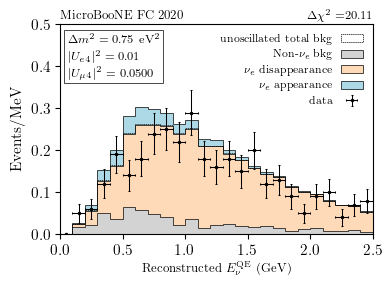

In [40]:
params_test = {'g': 1e-10, 'Ue4Sq': 0.01, 'Um4Sq': 0.05, 'm4': np.sqrt(0.754)}
rates_dic_osc_test = param_scan.get_nue_rates(params_test, oscillations=True, use_numu_MC=True, include_antineutrinos=True, decay=False, decouple_decay=False, disappearance=True, energy_degradation=False, n_replications=1, undo_numu_normalization=False)
make_micro_rate_plot(rates_dic_osc_test, params_test, 'test') 

In [41]:
from scipy.stats import chi2
confidence_level = 0.95

dof = 2

chi2_value = chi2.ppf(confidence_level, dof)

print(f"Chi-squared value for 95% confidence level with {dof} degrees of freedom: {chi2_value}")

Chi-squared value for 95% confidence level with 2 degrees of freedom: 5.99146454710798


In [37]:
import copy
from OscTools.micro_tools import muB_inclusive_data_path
def signal(rates, params, PC=False):
    # oscillation only MicroBooNE fully inclusive signal by unfolding MiniBooNE Signal
    uBFC_osc = param_scan.GBFC.unfold(rates["MC_nue_app_for_unfolding"])
    uBFC_osc = np.insert(uBFC_osc, 0, [0.0])
    uBFC_osc = np.append(uBFC_osc, 0.0)

    # MicroBooNE partially inclusive signal by unfolding MiniBooNE Signal
    MC_nue_app_for_unfolding2_osc = copy.deepcopy(rates["MC_nue_app_for_unfolding"])
    uBPC_osc = param_scan.GBPC.unfold(MC_nue_app_for_unfolding2_osc)
    uBPC_osc = np.insert(uBPC_osc, 0, [0.0])
    uBPC_osc = np.append(uBPC_osc, 0.0)

    uBtemp_osc = np.concatenate([uBFC_osc, uBPC_osc, np.zeros(85)])

    uB_signal_osc = uBPC_osc if PC else uBFC_osc

    return uBtemp_osc, uB_signal_osc

def make_micro_rate_plot_numu(rates_1, rates_2, params_1, params_2, name='micro_3+1_osc', PC=False, helicity = 'conserving'):
    fig, ax1 = pt.std_fig(figsize=(4.5,3))

    bins = np.array([0.0 + 0.1 * j for j in range(26)] + [10.0])
    bin_w = np.diff(bins)
    bin_c = bins[:-1] + bin_w/2

    uBtemp_osc_1, uB_signal_osc_1 = signal(rates_1, params_1, PC=False)
    uBtemp_osc_2, uB_signal_osc_2 = signal(rates_2, params_2, PC=False)
#     unfolding = micro.unfolder.MBtomuB(
#     analysis="1eX_PC" if PC else "1eX",
#     remove_high_energy=False,
#     unfold=True,
#     effNoUnfold=True,
#     which_template="2020",
#     )

    # MicroBooNE fully inclusive signal by unfolding MiniBooNE Signal
#     uB_signal = unfolding.unfold(rates["MC_nue_app_for_unfolding"])
#     uB_signal = np.insert(uB_signal, 0, [0.0])
#     uB_signal = np.append(uB_signal, 0.0)

    SAMPLE = "PC" if PC else "FC"
    other_bkg = np.load(files(micro.muB_inclusive_datarelease_path).joinpath(f'numuCC_{SAMPLE}_Bkg.npy').open('rb'))
    intrinsic_bkg = np.load(files(micro.muB_inclusive_datarelease_path).joinpath(f'numuCC_{SAMPLE}_Sig.npy').open('rb'))
    data = np.load(files(micro.muB_inclusive_datarelease_path).joinpath(f'numuCC_{SAMPLE}_Obs.npy').open('rb'))

    # \nu_e disappearance signal replacement (oscillation term -- lightgreen)
    NuEReps1 = DecayMuBNuEDis(
    params_1,
    oscillations=True,
    decay=False,
    decouple_decay=False,
    disappearance=True,
    energy_degradation=True,
    helicity=helicity,
    )

    NuEReps2 = DecayMuBNuEDis(
    params_2,
    oscillations=True,
    decay=False,
    decouple_decay=False,
    disappearance=True,
    energy_degradation=True,
    helicity=helicity,
    )

    # \nu_mu disappearance signal replacement
    
    NuMuReps1 = DecayMuBNuMuDis(
    params_1,
    oscillations=True,
    decay=False,
    decouple_decay=False,
    disappearance=True,
    energy_degradation=True,
    helicity=helicity,
    )

    NuMuReps2 = DecayMuBNuMuDis(
    params_2,
    oscillations=True,
    decay=False,
    decouple_decay=False,
    disappearance=True,
    energy_degradation=True,
    helicity=helicity,
    )
    # MicroBooNE
    MuB_chi2_1 = Decay_muB_OscChi2(
        params_1,
        uBtemp_osc_1,
        constrained=False,
        sigReps=[NuEReps1[0], NuEReps1[1], NuMuReps1[0], NuMuReps1[1], None, None, None],
        RemoveOverflow=True,
        oscillations=True,
        decay=True,
        decouple_decay=False,
        disappearance=True,
        energy_degradation=True,
        helicity=helicity,
    )

    MuB_chi2_2 = Decay_muB_OscChi2(
        params_2,
        uBtemp_osc_2,
        constrained=False,
        sigReps=[NuEReps2[0], NuEReps2[1], NuMuReps2[0], NuMuReps2[1], None, None, None],
        RemoveOverflow=True,
        oscillations=True,
        decay=True,
        decouple_decay=False,
        disappearance=True,
        energy_degradation=True,
        helicity=helicity,
    )

    ###################################### 
    if TOTAL_RATE:
        units= 1
        ax1.set_ylabel(r"Events")
    else:
        units = 1/bin_w/1e3
        ax1.set_ylabel(r"Events/MeV")

    # plot data
    pt.data_plot(ax1, 
            X=bin_c,
            Y=data*units, 
            xerr=bin_w/2, 
            yerr=np.sqrt(data)*units,
            zorder=3)
    
    ax1.hist(bins[:-1],
            bins=bins,
            weights=((other_bkg + intrinsic_bkg)) * units,
            edgecolor='black',
            lw=1.0,
            ls=(1,(3,1)),
            label=r'unoscillated $\nu_\mu$ rate',
            histtype='step',
            zorder=1.8)

    ax1.hist(bins[:-1],
            bins=bins,
            weights=(NuMuReps1[1 if PC else 0])*units,
            edgecolor=pointAcolor,
            facecolor='None',
            lw=1.25,
            label=r'$\nu_\mu$ disappearance (A)',
            histtype='stepfilled',
            zorder=1.6)

    ax1.hist(bins[:-1],
            bins=bins,
            weights=(NuMuReps2[1 if PC else 0])*units,
            edgecolor=pointBcolor,
            facecolor='None',
            lw=1.25,
            label=r'$\nu_\mu$ disappearance (B)',
            histtype='stepfilled',
            zorder=1.6)

    # ax1.legend(loc='upper right', fontsize=8, markerfirst=False, ncol=1)
    ax1.legend(fontsize=8.5, markerfirst=False, ncol=1, handlelength=1, loc='upper right', borderpad=0.2, labelspacing=0.75, handletextpad=0.5, columnspacing=1)
    ax1.annotate(text=fr'MicroBooNE FC 2021 $\vert$ $\nu_\mu$CC', xy=(0.0,1.025), xycoords='axes fraction', fontsize=11)
    ax1.annotate(text=rf'\noindent Point A) $\Delta \chi^2_{{\rm \mu B}} = {MuB_chi2_1 - 90:.0f}$', 
                xy=(0.65,0.5), 
                xycoords='axes fraction', 
                fontsize=8.5,
                color=pointAcolor)

    ax1.annotate(text=rf'\noindent Point B) $\Delta \chi^2_{{\rm \mu B}} = {MuB_chi2_2 - 90:.1f}$',
                xy=(0.65,0.4),
                xycoords='axes fraction',
                fontsize=8.5,
                color=pointBcolor)
    ax1.set_xlabel(r"Reconstructed $E_\nu^{\rm QE}$ (GeV)", fontsize=9, labelpad=2.5)
    ax1.set_xticks([0,0.5,1.0,1.5,2.0, 2.5])
    ax1.set_xlim(0.0,2.5)
    ax1.set_ylim(0,60)

#     fig.savefig(f"{PATH_PLOTS}/Micro_{name}_{'PC' if PC else 'FC'}.png", dpi=400)
    fig.savefig(f"{PATH_PLOTS}/Micro_{name}_{'PC' if PC else 'FC'}.pdf", dpi=400)

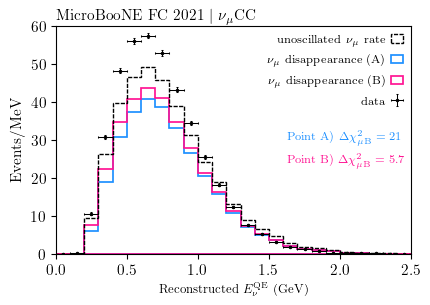

In [38]:
make_micro_rate_plot_numu(rates_BSM1, rates_BSM2, params_BSM1, params_BSM2, 'numu')